In [1]:
# Specify the directory containing the videos
#video_dir = "C://Users//Sinchan A//Desktop//Internship//videos//fake//"

# Create a directory to store frames
#frame_dir = "C://Users//Sinchan A//Desktop//Internship//vid//fake"
#os.makedirs(frame_dir, exist_ok=True)

# Specify the desired frames per second (FPS)
#desired_fps = 4

# Loop through all video files in the directory
#for video_path in Path(video_dir).glob("*.mp4"):
    # Load the video
 #   video = cv2.VideoCapture(str(video_path))

    # Get the original FPS of the video
  #  original_fps = video.get(cv2.CAP_PROP_FPS)

    # Calculate the frame skip rate based on the desired FPS
   # frame_skip = int(original_fps / desired_fps)

    # Initialize frame counter
    #frame_count = 0

    # Loop through the video
    #while True:
        # Read a frame from the video
     #   ret, frame = video.read()

        # Break the loop if no more frames
      #  if not ret:
       #     break

        # Skip frames based on the desired FPS
        #if frame_count % frame_skip == 0:
            # Save the frame as an image
         #   frame_name = f"{video_path.stem}_{frame_count // frame_skip}.jpg"
          #  frame_path = os.path.join(frame_dir, frame_name)
           # cv2.imwrite(frame_path, frame)

        # Update frame counter
       # frame_count += 1

    # Release the video capture object
   # video.release()

#    print(f"Converted {video_path.name} to {frame_count // frame_skip} frames at {desired_fps} FPS.")


Training Set Performance:
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1-Score: 1.000
ROC AUC: 1.000


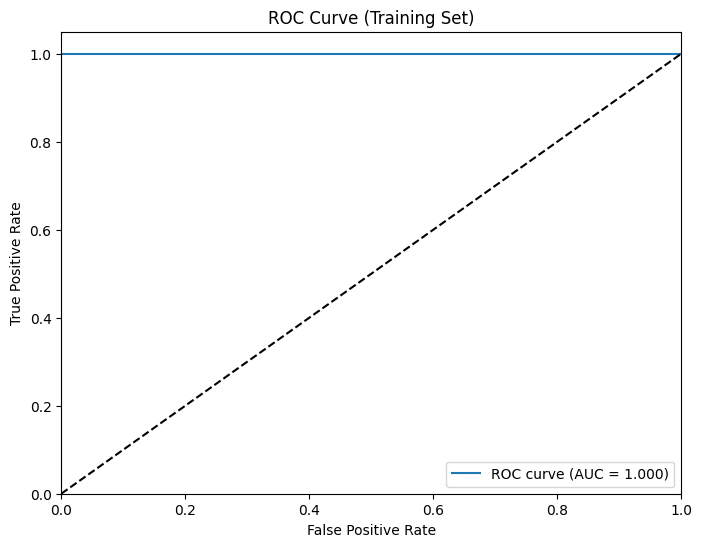

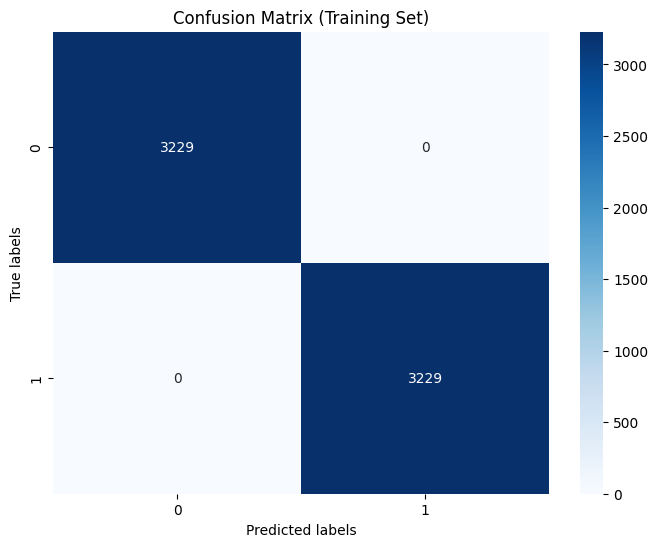

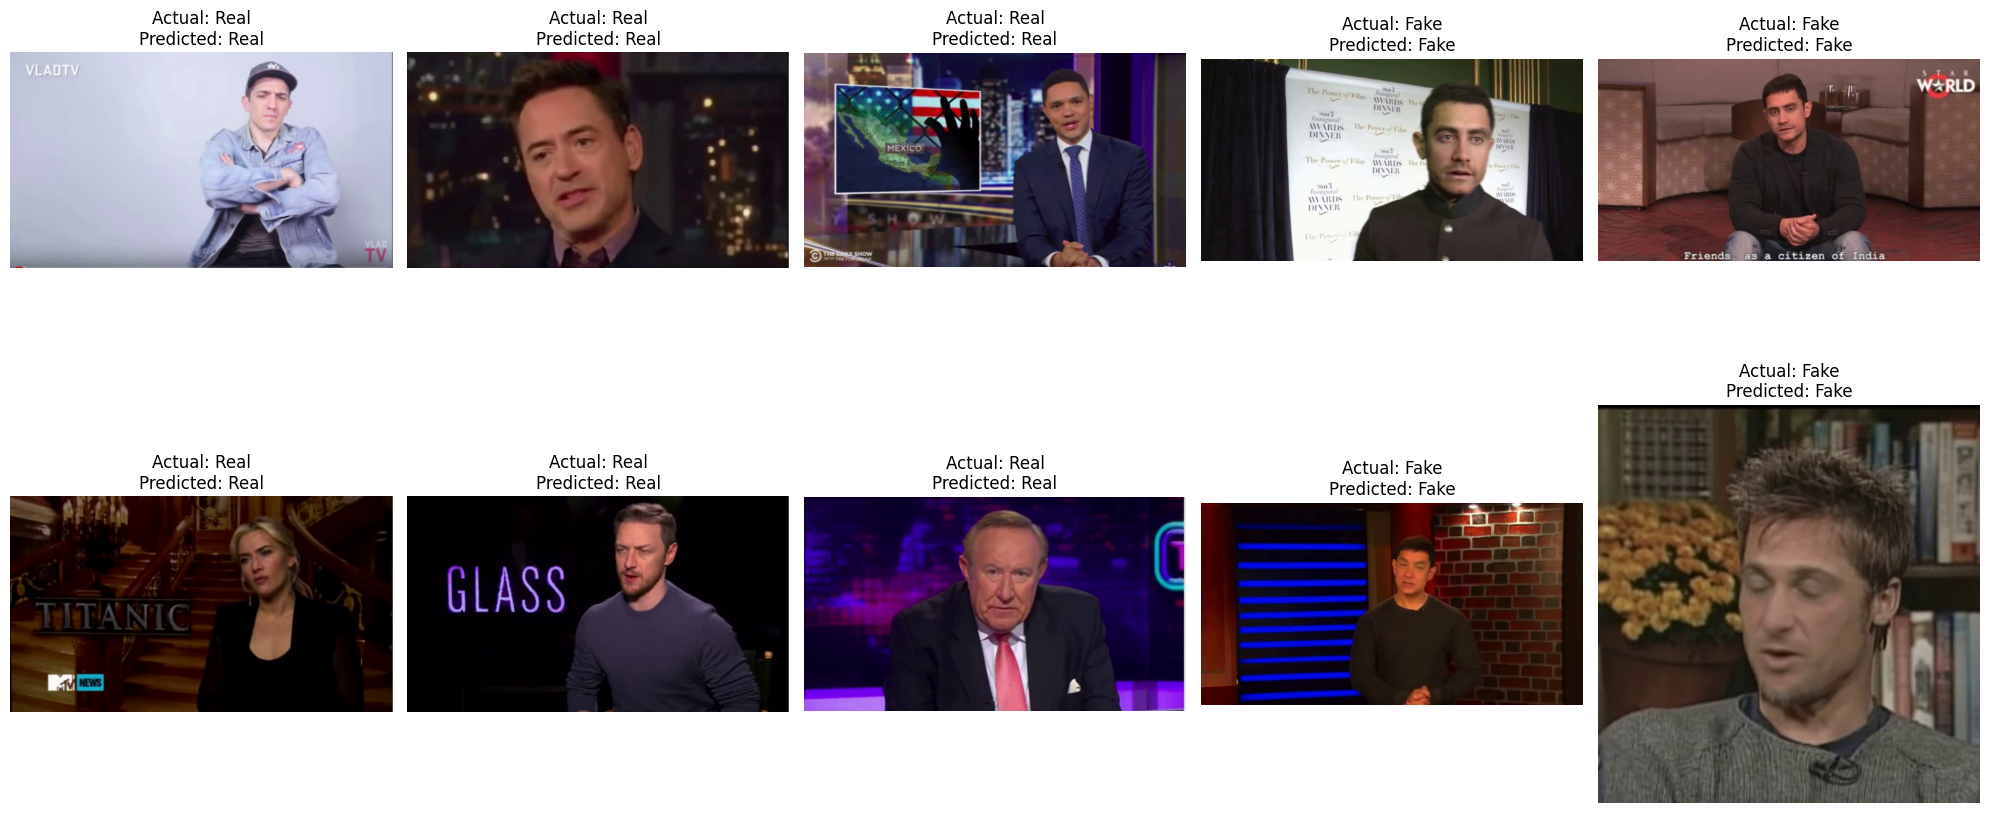


Validation Set Performance:
Accuracy: 0.998
Precision: 0.995
Recall: 1.000
F1-Score: 0.998
ROC AUC: 1.000


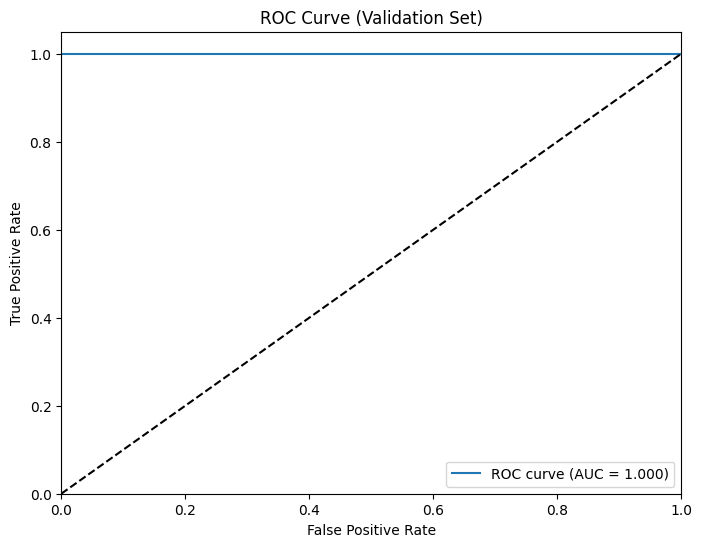

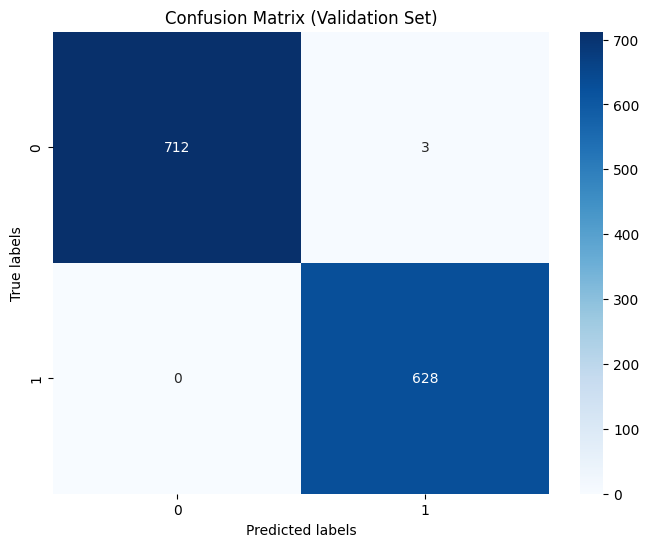

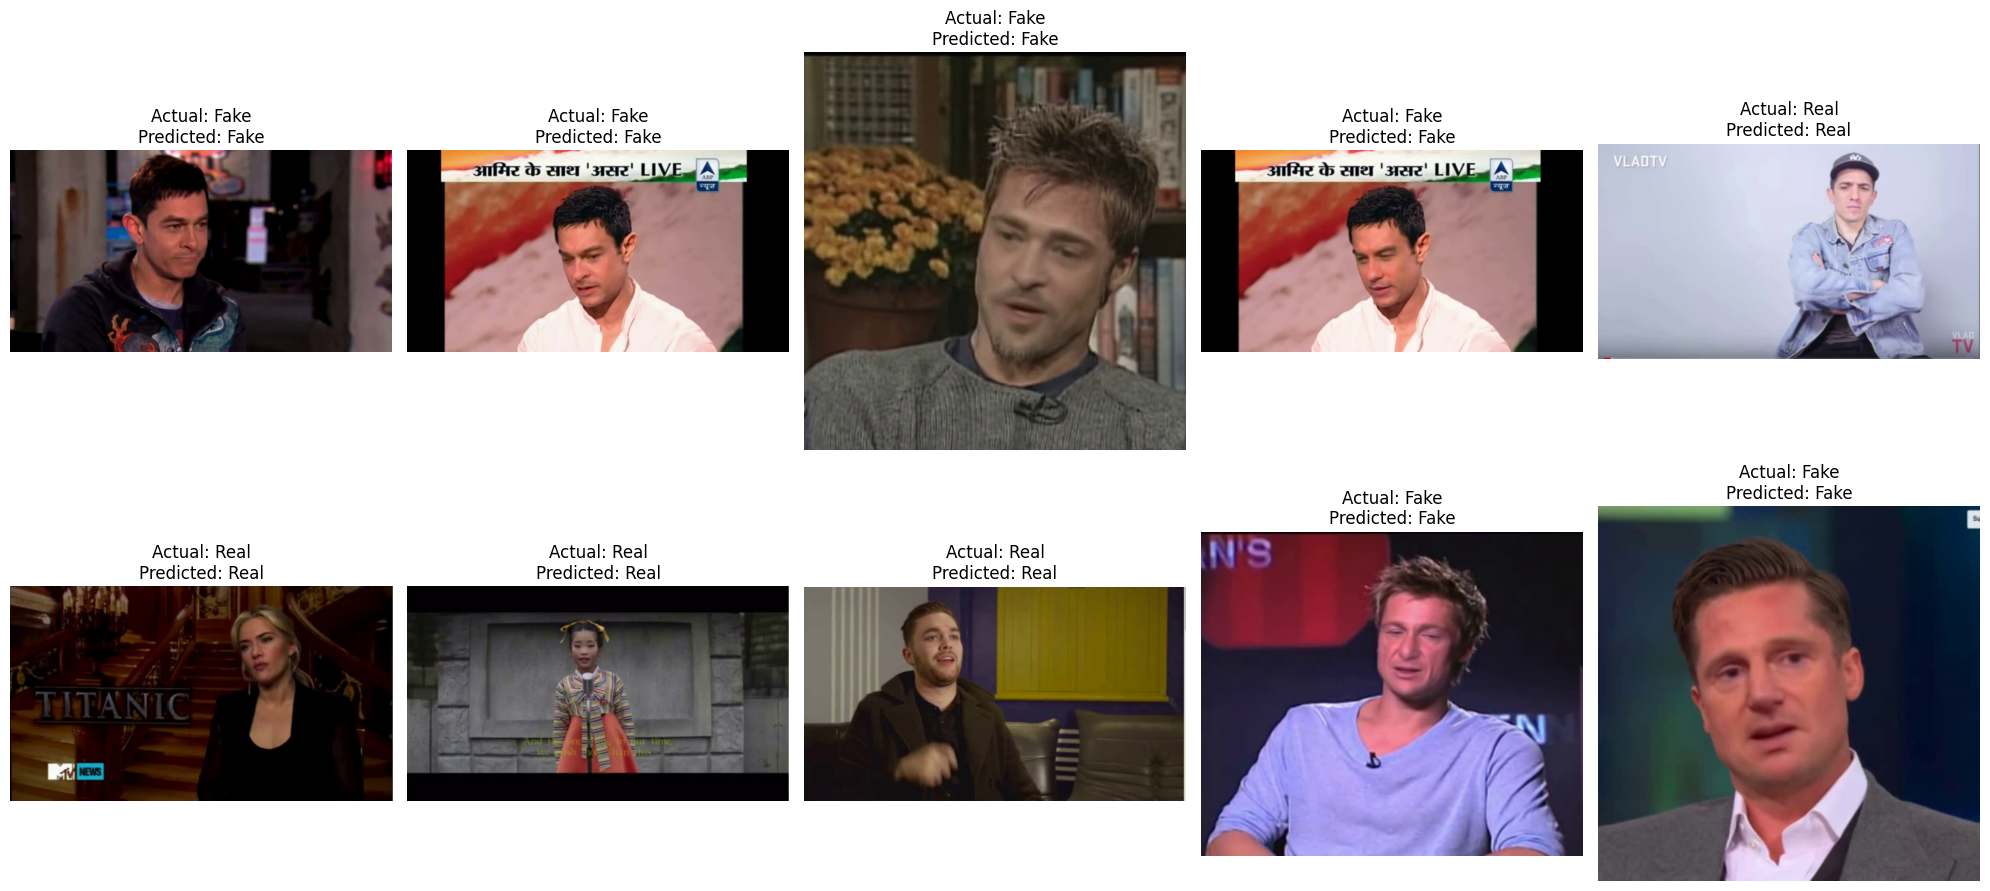


Test Set Performance:
Accuracy: 0.999
Precision: 0.998
Recall: 1.000
F1-Score: 0.999
ROC AUC: 1.000


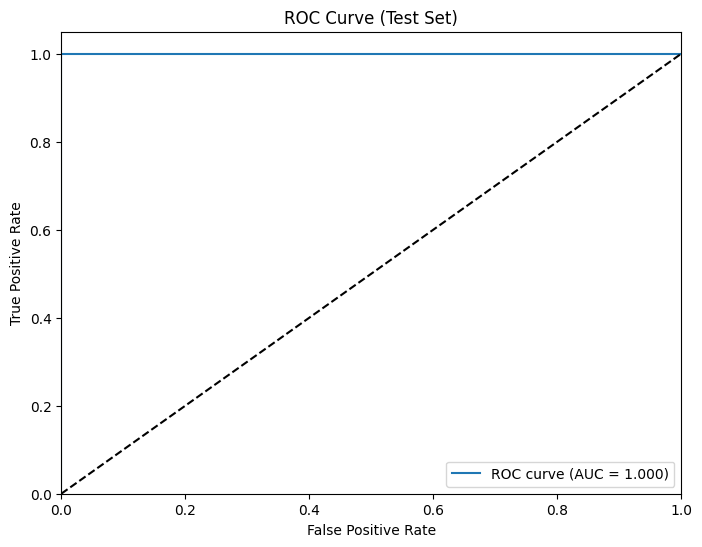

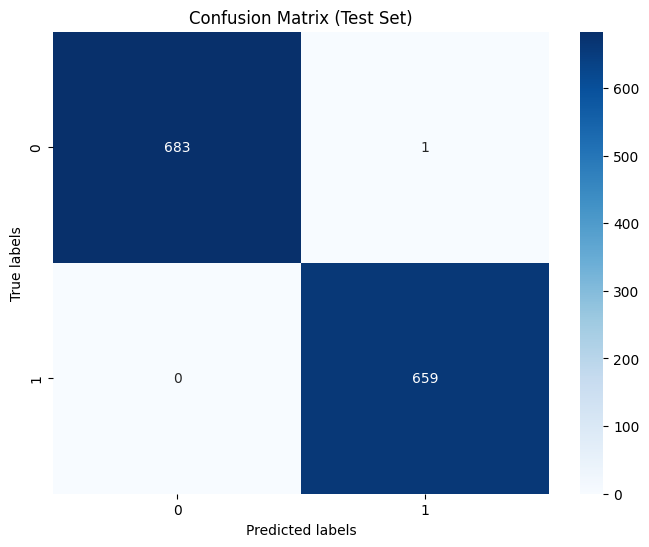

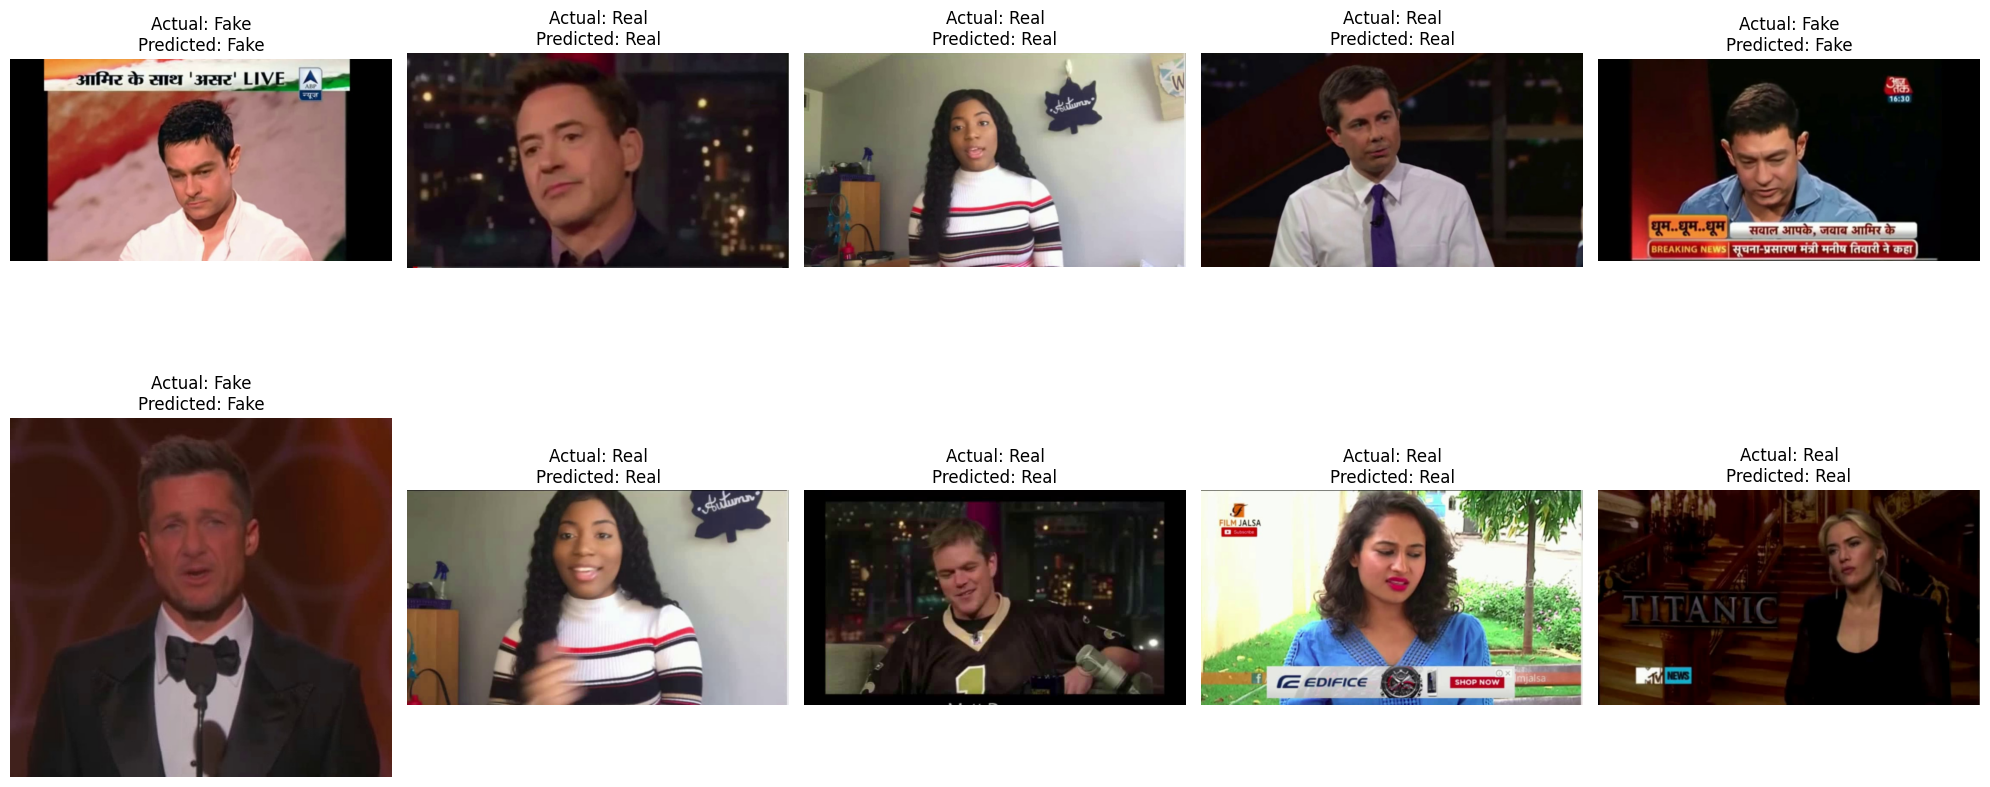

In [3]:
import numpy as np
import os
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from collections import Counter

def estimate_jpeg_quality(img):
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    laplacian = cv2.convertScaleAbs(laplacian)
    return np.mean(laplacian)

def extract_features(image_path):
    try:
        img = Image.open(image_path)
        img_cv = cv2.imread(image_path)
        if img_cv is None:
            print(f"Warning: Unable to read {image_path} with OpenCV. Skipping...")
            return None
    except:
        print(f"Error: Unable to open {image_path}. Skipping...")
        return None
    
    features = []
    
    # 1. Estimated JPEG Quality
    jpeg_quality = estimate_jpeg_quality(img_cv)
    features.append(jpeg_quality)
    
    # 2. Image sharpness (using variance of Laplacian)
    sharpness = cv2.Laplacian(img_cv, cv2.CV_64F).var()
    features.append(sharpness)
    
    # 3. RGB channel statistics
    for channel in range(3):
        channel_data = np.array(img)[:,:,channel].flatten()
        features.extend([np.mean(channel_data), np.std(channel_data), np.var(channel_data)])
    
    # 4. Image entropy (measure of image complexity)
    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    entropy = cv2.calcHist([gray], [0], None, [256], [0, 256])
    entropy = entropy / entropy.sum()
    entropy = -np.sum(entropy * np.log2(entropy + 1e-10))
    features.append(entropy)
    
    # 5. Edge density (using Sobel operator)
    sobel_x = cv2.Sobel(img_cv, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_cv, cv2.CV_64F, 0, 1, ksize=3)
    edge_density = np.mean(np.sqrt(sobel_x**2 + sobel_y**2))
    features.append(edge_density)
    
    # 6. Color Range (max - min) for each channel
    for i in range(3):
        channel = img_cv[:,:,i]
        features.append(np.max(channel) - np.min(channel))
    
    return features

def load_dataset(real_path, fake_path):
    X = []
    y = []
    image_paths = []
    
    for img_name in os.listdir(real_path):
        img_path = os.path.join(real_path, img_name)
        features = extract_features(img_path)
        if features is not None:
            X.append(features)
            y.append(0)  # 0 for real
            image_paths.append(img_path)
    
    for img_name in os.listdir(fake_path):
        img_path = os.path.join(fake_path, img_name)
        features = extract_features(img_path)
        if features is not None:
            X.append(features)
            y.append(1)  # 1 for fake
            image_paths.append(img_path)
    
    return np.array(X), np.array(y), image_paths

def evaluate_model(model, X, y, image_paths, set_name):
    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    fpr, tpr, _ = roc_curve(y, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    print(f"\n{set_name} Performance:")
    print(f"Accuracy: {accuracy_score(y, y_pred):.3f}")
    print(f"Precision: {precision_score(y, y_pred):.3f}")
    print(f"Recall: {recall_score(y, y_pred):.3f}")
    print(f"F1-Score: {f1_score(y, y_pred):.3f}")
    print(f"ROC AUC: {roc_auc:.3f}")
    
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve ({set_name})')
    plt.legend(loc="lower right")
    plt.show()
    
    # Plot confusion matrix
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title(f'Confusion Matrix ({set_name})')
    plt.show()

    # Display some images with their actual and predicted labels
    num_images = 10  # Number of images to display
    indices = np.random.choice(len(image_paths), num_images, replace=False)
    
    plt.figure(figsize=(20, 10))
    for i, idx in enumerate(indices):
        img = cv2.imread(image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        actual_label = 'Real' if y[idx] == 0 else 'Fake'
        predicted_label = 'Real' if y_pred[idx] == 0 else 'Fake'
        
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Load original dataset
original_real_path = "C://Users//Sinchan A//Desktop//Internship//vid//real"
original_fake_path = "C://Users//Sinchan A//Desktop//Internship//vid//fake"
X, y, image_paths = load_dataset(original_real_path, original_fake_path)

# Split the data into train, validation, and test sets
X_train, X_temp, y_train, y_temp, image_paths_train, image_paths_temp = train_test_split(X, y, image_paths, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test, image_paths_val, image_paths_test = train_test_split(X_temp, y_temp, image_paths_temp, test_size=0.5, random_state=42)

# oversampling the train dataset using SMOTE
smt = SMOTE()
X_train, y_train = smt.fit_resample(X_train, y_train)

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(random_state=42)),
            ('gb', GradientBoostingClassifier(random_state=42)),
            ('svm', SVC(probability=True, random_state=42))
        ],
        final_estimator=LogisticRegression(random_state=42)
    ))
])

# Define the parameter grid for RandomizedSearchCV
param_grid = {
    'classifier__rf__n_estimators': [50, 100, 200],
    'classifier__rf__max_depth': [None, 10, 20, 30],
    'classifier__gb__n_estimators': [50, 100, 200],
    'classifier__gb__learning_rate': [0.01, 0.1, 0.2],
    'classifier__svm__C': [0.1, 1, 10],
    'classifier__svm__kernel': ['rbf', 'poly'],
    'classifier__final_estimator__C': [0.1, 1, 10]
}

# Perform RandomizedSearchCV
random_search = RandomizedSearchCV(pipeline, param_distributions=param_grid, n_iter=50, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

# Get the best model
best_model = random_search.best_estimator_

# Evaluate on training set
evaluate_model(best_model, X_train, y_train, image_paths_train, "Training Set")

# Evaluate on validation set
evaluate_model(best_model, X_val, y_val, image_paths_val, "Validation Set")

# Evaluate on test set
evaluate_model(best_model, X_test, y_test, image_paths_test, "Test Set")
